# Controlled rock-density sensitivity comparison

This notebook evaluates the deterministic response of seven reconstructed conventional burden equations to changes in rock density.

Rock density is varied while hole diameter, uniaxial compressive strength, explosive density, explosive type, and the Ash burden ratio remain fixed at the reconstructed Gole Gohar reference values.

The analysis is a research comparison of equation behavior. It is not a calibrated uncertainty analysis, a universal geological classification, or a validated operational blast-design recommendation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from blastdesign import (
    DEFAULT_ROCK_DENSITY_GRID_G_CM3,
    build_gole_gohar_rock_density_sensitivity_table,
    build_model_rock_density_response_summary,
    build_rock_density_ensemble_summary,
)


PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIRECTORY = PROJECT_ROOT / "data" / "processed"
FIGURE_DIRECTORY = PROJECT_ROOT / "outputs" / "figures"

DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

REFERENCE_ROCK_DENSITY_G_CM3 = 4.37
REFERENCE_EXPLOSIVE_DENSITY_G_CM3 = 0.85

DEFAULT_ROCK_DENSITY_GRID_G_CM3

(1.8, 2.1, 2.4, 2.6, 2.75, 3.0, 3.3, 3.75, 4.0, 4.37, 4.8, 5.3)

## Method

The analysis uses a controlled one-factor-at-a-time design:

- Rock density is varied over the broad exploratory grid defined by the package.
- The grid spans low-density rock, common competent host-rock densities, dense ore-rich rock, and uncommon high-density endmembers.
- The reconstructed reference rock density is 4.37 g/cm³.
- Explosive density remains fixed at 0.85 g/cm³.
- Consequently, the explosive-to-rock density ratio changes as rock density changes.
- All other reconstructed Gole Gohar inputs remain fixed.

The grid is deliberately broad, but it is not a frequency distribution or a universal model-validity domain. Mineral density, grain density, dry-bulk density, saturated-bulk density, and in-situ rock-mass density must not be treated as interchangeable.

Only the Konya 1972 and Konya 1983 equations explicitly use rock density in the current seven-model reconstruction.

In [2]:
model_outputs = (
    build_gole_gohar_rock_density_sensitivity_table()
)

ensemble_summary = (
    build_rock_density_ensemble_summary(
        model_outputs
    )
)

model_response_summary = (
    build_model_rock_density_response_summary(
        model_outputs
    )
)

display(model_outputs)
display(ensemble_summary)
display(model_response_summary)

,rock_density_g_cm3,explosive_to_rock_density_ratio,model_id,model_name,burden_m
0,1.8,0.472222,CONV_ASH,Ash,6.275000
1,1.8,0.472222,CONV_BHANDARI,Bhandari,6.874000
2,1.8,0.472222,CONV_JIMENO,Lopez Jimeno,5.773000
3,1.8,0.472222,CONV_KONYA_1972,Konya 1972,7.406855
4,1.8,0.472222,CONV_KONYA_1983,Konya 1983,7.362667
...,...,...,...,...,...
79,5.3,0.160377,CONV_JIMENO,Lopez Jimeno,5.773000
80,5.3,0.160377,CONV_KONYA_1972,Konya 1972,5.186361
81,5.3,0.160377,CONV_KONYA_1983,Konya 1983,5.484113
82,5.3,0.160377,CONV_RUSTAN,Rustan,6.983189


,rock_density_g_cm3,explosive_to_rock_density_ratio,model_count,mean_burden_m,median_burden_m,minimum_burden_m,maximum_burden_m,range_m
0,1.80,0.472222,7,6.644869,6.874000,5.773000,7.406855,1.633855
1,2.10,0.404762,7,6.534334,6.874000,5.773000,7.039493,1.266493
2,2.40,0.354167,7,6.447441,6.651500,5.773000,6.983189,1.210189
3,2.60,0.326923,7,6.398911,6.487385,5.773000,6.983189,1.210189
4,2.75,0.309091,7,6.366377,6.379964,5.773000,6.983189,1.210189
5,3.00,0.283333,7,6.318170,6.257830,5.773000,6.983189,1.210189
6,3.30,0.257576,7,6.268323,6.069636,5.773000,6.983189,1.210189
7,3.75,0.226667,7,6.205939,5.883440,5.773000,6.983189,1.210189
8,4.00,0.212500,7,6.176247,5.839370,5.691071,6.983189,1.292118
9,4.37,0.194508,7,6.137371,5.839370,5.527324,6.983189,1.455865


,model_id,model_name,distinct_burden_count,responds_to_rock_density,lower_rock_density_g_cm3,upper_rock_density_g_cm3,burden_at_lower_endpoint_m,reference_rock_density_g_cm3,reference_density_ratio,reference_burden_m,burden_at_upper_endpoint_m,endpoint_change_m,endpoint_change_percent,burden_range_m
0,CONV_ASH,Ash,1,False,1.8,5.3,6.275000,4.37,0.194508,6.275000,6.275000,0.000000,0.000000,0.000000
1,CONV_BHANDARI,Bhandari,1,False,1.8,5.3,6.874000,4.37,0.194508,6.874000,6.874000,0.000000,0.000000,0.000000
2,CONV_JIMENO,Lopez Jimeno,1,False,1.8,5.3,5.773000,4.37,0.194508,5.773000,5.773000,0.000000,0.000000,0.000000
3,CONV_KONYA_1972,Konya 1972,12,True,1.8,5.3,7.406855,4.37,0.194508,5.527324,5.186361,-2.220494,-29.978906,2.220494
4,CONV_KONYA_1983,Konya 1983,12,True,1.8,5.3,7.362667,4.37,0.194508,5.689716,5.484113,-1.878553,-25.514580,1.878553
5,CONV_RUSTAN,Rustan,1,False,1.8,5.3,6.983189,4.37,0.194508,6.983189,6.983189,0.000000,0.000000,0.000000
6,CONV_TATIYA,Tatiya–Al-Ajmi,1,False,1.8,5.3,5.839370,4.37,0.194508,5.839370,5.839370,0.000000,0.000000,0.000000


In [3]:
model_outputs.to_csv(
    DATA_DIRECTORY
    / "rock_density_sensitivity_model_outputs.csv",
    index=False,
)

ensemble_summary.to_csv(
    DATA_DIRECTORY
    / "rock_density_sensitivity_ensemble_summary.csv",
    index=False,
)

model_response_summary.to_csv(
    DATA_DIRECTORY
    / "rock_density_sensitivity_model_response_summary.csv",
    index=False,
)

print(
    "Saved:",
    len(model_outputs),
    "model-output rows,",
    len(ensemble_summary),
    "ensemble-summary rows, and",
    len(model_response_summary),
    "model-response rows.",
)

Saved: 84 model-output rows, 12 ensemble-summary rows, and 7 model-response rows.


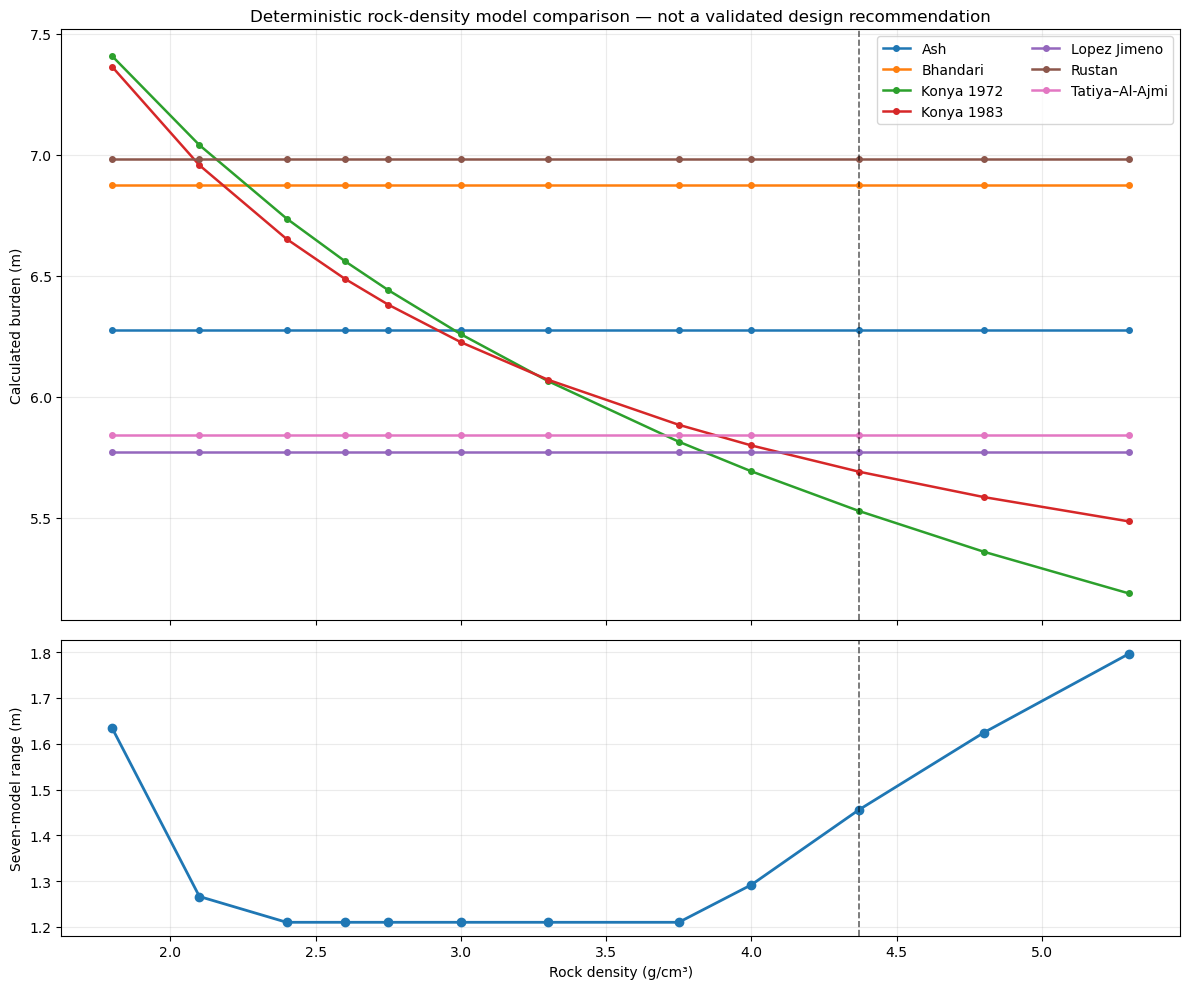

Saved figure: C:\Users\A.Mehregan\Projects\BlastDesign-AI\outputs\figures\rock_density_sensitivity_comparison.png


In [4]:
pivot_table = model_outputs.pivot(
    index="rock_density_g_cm3",
    columns="model_name",
    values="burden_m",
)

figure, axes = plt.subplots(
    2,
    1,
    figsize=(12, 10),
    sharex=True,
    gridspec_kw={
        "height_ratios": [2, 1],
    },
)

for model_name in pivot_table.columns:
    axes[0].plot(
        pivot_table.index,
        pivot_table[model_name],
        marker="o",
        linewidth=1.8,
        markersize=4,
        label=model_name,
    )

axes[0].axvline(
    REFERENCE_ROCK_DENSITY_G_CM3,
    color="black",
    linestyle="--",
    linewidth=1.2,
    alpha=0.6,
)

axes[0].set_ylabel("Calculated burden (m)")
axes[0].set_title(
    "Deterministic rock-density model comparison — "
    "not a validated design recommendation"
)
axes[0].grid(True, alpha=0.25)
axes[0].legend(
    loc="best",
    ncol=2,
)

axes[1].plot(
    ensemble_summary["rock_density_g_cm3"],
    ensemble_summary["range_m"],
    marker="o",
    linewidth=2.0,
)

axes[1].axvline(
    REFERENCE_ROCK_DENSITY_G_CM3,
    color="black",
    linestyle="--",
    linewidth=1.2,
    alpha=0.6,
)

axes[1].set_xlabel("Rock density (g/cm³)")
axes[1].set_ylabel("Seven-model range (m)")
axes[1].grid(True, alpha=0.25)

figure.tight_layout()

figure_path = (
    FIGURE_DIRECTORY
    / "rock_density_sensitivity_comparison.png"
)

figure.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Saved figure: {figure_path}")

In [5]:
responsive_models = model_response_summary.loc[
    model_response_summary[
        "responds_to_rock_density"
    ]
].copy()

display(
    responsive_models[
        [
            "model_id",
            "reference_burden_m",
            "burden_at_lower_endpoint_m",
            "burden_at_upper_endpoint_m",
            "endpoint_change_m",
            "endpoint_change_percent",
            "burden_range_m",
        ]
    ]
)

reference_summary = ensemble_summary.loc[
    ensemble_summary[
        "rock_density_g_cm3"
    ].eq(
        REFERENCE_ROCK_DENSITY_G_CM3
    )
].iloc[0]

maximum_range_row = ensemble_summary.loc[
    ensemble_summary["range_m"].idxmax()
]

minimum_range_row = ensemble_summary.loc[
    ensemble_summary["range_m"].idxmin()
]

print(
    "Reference seven-model range:",
    f"{reference_summary['range_m']:.6f} m",
)

print(
    "Maximum sampled seven-model range:",
    f"{maximum_range_row['range_m']:.6f} m",
    "at",
    f"{maximum_range_row['rock_density_g_cm3']:.2f} g/cm³",
)

print(
    "Minimum sampled seven-model range:",
    f"{minimum_range_row['range_m']:.6f} m",
    "at",
    f"{minimum_range_row['rock_density_g_cm3']:.2f} g/cm³",
)

print(
    "Reference explosive-to-rock density ratio:",
    f"{reference_summary['explosive_to_rock_density_ratio']:.6f}",
)

,model_id,reference_burden_m,burden_at_lower_endpoint_m,burden_at_upper_endpoint_m,endpoint_change_m,endpoint_change_percent,burden_range_m
3,CONV_KONYA_1972,5.527324,7.406855,5.186361,-2.220494,-29.978906,2.220494
4,CONV_KONYA_1983,5.689716,7.362667,5.484113,-1.878553,-25.514580,1.878553


Reference seven-model range: 1.455865 m
Maximum sampled seven-model range: 1.796828 m at 5.30 g/cm³
Minimum sampled seven-model range: 1.210189 m at 2.40 g/cm³
Reference explosive-to-rock density ratio: 0.194508


## Interpretation

Only the Konya 1972 and Konya 1983 equations respond numerically to rock density in the current seven-model reconstruction. Both use the explosive-to-rock density ratio, so their calculated burdens decrease as rock density increases while explosive density remains fixed.

The other five equations remain constant because rock density is not an explicit input to their reconstructed mathematical forms. This structural insensitivity must not be interpreted as evidence that rock density has no physical influence on blasting outcomes.

The sampled interval of 1.80–5.30 g/cm³ is intentionally broad:

- Its central region contains many common competent host-rock densities.
- Its lower end represents comparatively low-density or porous rock.
- Its upper end includes unusually dense ore-rich rock and mineral-dominated endmembers.
- The sampled values are not equally common and do not define a universal geological or operational range.

The reference value of 4.37 g/cm³ is retained from the reconstructed Gole Gohar scenario. Its original measurement basis should be audited before interpreting it as grain, dry-bulk, saturated-bulk, or in-situ rock-mass density.

Changes in the seven-model range describe deterministic structural disagreement among empirical equations. They are not:

- Statistical confidence intervals.
- Calibrated prediction intervals.
- Evidence that one model is more accurate.
- A recommended rock-density range.
- A site-specific burden recommendation.

The decision gate therefore remains `RESEARCH_COMPARATOR_ONLY`.